# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [1]:
from base64 import encode
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.graphics.gofplots
from statsmodels.formula.api import ols
import statsmodels.api as sm
# Add your additional imports as needed
# from sklearn...

# import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

---
## Load Data

In [2]:
train = pd.read_csv('data/train.csv', encoding='utf-8')
test = pd.read_csv('data/test.csv', encoding='utf-8')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


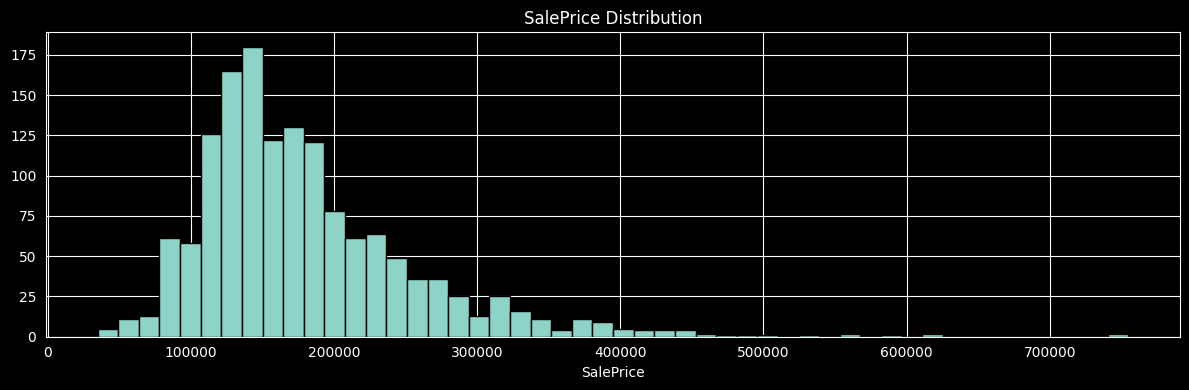

Skewness: 1.883


In [3]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

In [4]:
# Transforming prices into logs to have a normal distribution. Adding them to the train dataframe
train["SalePrice_log"] = np.log(train['SalePrice'])
sales_price = train['SalePrice_log']

# mean, variance, SD
mean_sales_price = np.mean(sales_price)
n = len(sales_price)
var_sales_price = sum((x - mean_sales_price)**2 for x in sales_price)/(n-1)
std_sales_price = sqrt(var_sales_price)

print(sales_price.describe())

# So, I've tried this Shapiro test as suggested, but it gives a misleading result because it only works with smaller samples (as shown in the second print)
print(stats.shapiro(sales_price))

# random sample from sales_log with n=100
print(stats.shapiro(sales_price.sample(100)))


count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice_log, dtype: float64
ShapiroResult(statistic=np.float64(0.9912067503807811), pvalue=np.float64(1.1490615527264654e-07))
ShapiroResult(statistic=np.float64(0.9892565720373521), pvalue=np.float64(0.6048624123380735))


((array([-3.30513952, -3.04793228, -2.90489705, ...,  2.90489705,
          3.04793228,  3.30513952], shape=(1460,)),
  array([10.46024211, 10.47194981, 10.54270639, ..., 13.34550693,
         13.5211395 , 13.53447303], shape=(1460,))),
 (np.float64(0.3982622308161888),
  np.float64(12.024050901109383),
  np.float64(0.9953761475636613)))

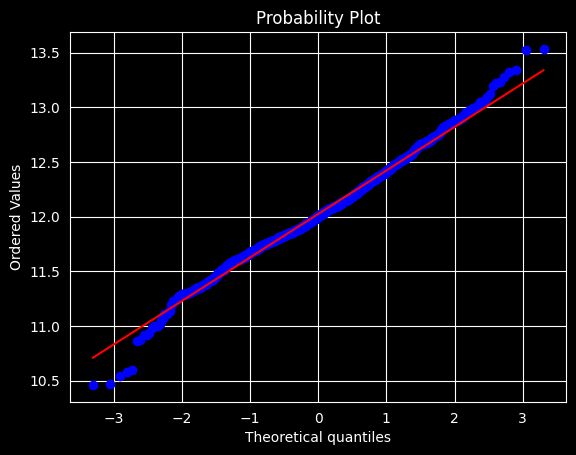

In [5]:
# To prove that we now have a normal distribution let's do a QQ plot
stats.probplot(sales_price, dist="norm", plot=plt)
# normal enough I think

Mean's confidence interval at 95%: [12.003544164729277, 12.04455763748949]
Skewness: 0.121


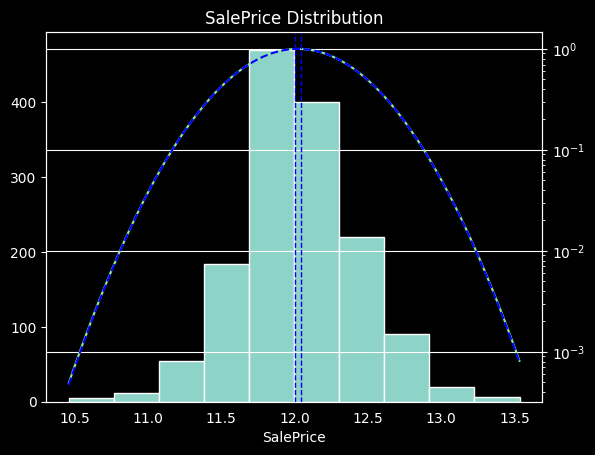

In [6]:
# Confidence interval for the mean of log price
alpha = 0.05
df = n - 1
t_crit = stats.t.ppf(1-alpha/2, df)
margin_error = t_crit * (std_sales_price/sqrt(n))
lower_limit = mean_sales_price - margin_error
upper_limit = mean_sales_price + margin_error
p = stats.t.cdf(t_crit, df)


fig, ax = plt.subplots()
plt.hist(sales_price)
x = np.linspace(np.min(sales_price), np.max(sales_price), 1000)

t_dist = stats.t(df, loc=mean_sales_price, scale=std_sales_price)
t_but_normal = stats.norm(mean_sales_price, std_sales_price)
ax2 = ax.twinx()
ax.grid(False)
ax2.plot(x, t_dist.pdf(x), color='lightgreen', label="T Distribution")
ax2.plot(x, t_but_normal.pdf(x), color='blue', linestyle="--", label="Normal")
ax2.set_yscale('log')
ax.set_title('SalePrice Distribution')
ax.set_xlabel('SalePrice')
plt.axvline(lower_limit, color='blue', linestyle='--', linewidth=1)
plt.axvline(upper_limit, color='blue', linestyle='--', linewidth=1)


print(f"Mean's confidence interval at 95%: [{lower_limit}, {upper_limit}]")
print(f'Skewness: {train["SalePrice_log"].skew():.3f}')
plt.show()

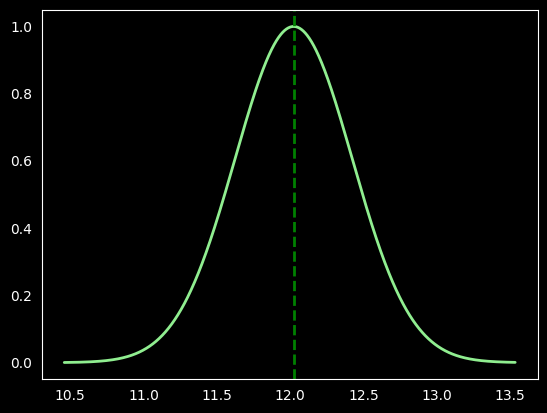

In [7]:
x = np.linspace(np.min(sales_price), np.max(sales_price), 1000)
t_pdf = stats.t.pdf(x, df, loc=mean_sales_price, scale=std_sales_price)
plt.plot(x, t_pdf, color='lightgreen', linewidth=2)
plt.axvline(mean_sales_price, color='green', linestyle='--', linewidth=2)
plt.grid(False)

{'whiskers': [<matplotlib.lines.Line2D at 0x7f817dd22cf0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f817dd22f90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f817dd22ba0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f817dd23230>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f817dd23380>],
 'means': []}

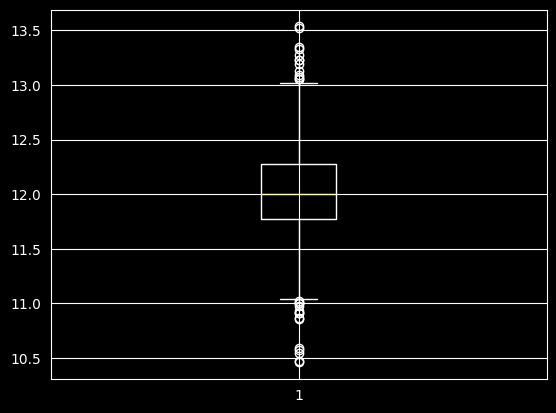

In [8]:
# Outliers
plt.boxplot(train["SalePrice_log"])

In [9]:
# CI for variance
a = stats.chi2.ppf(alpha/2, df)
b = stats.chi2.ppf(1-alpha/2, df)

# ((n-1)*sample_var)/b < pop_var < ((n-1)*sample_var)/a
var_lower_limit = (df*var_sales_price)/b
var_upper_limit = (df*var_sales_price)/a

print(f"Confidence Interval (95%) for the variance: [{var_lower_limit}, {var_upper_limit}]")


Confidence Interval (95%) for the variance: [0.14858771791596836, 0.17180448306911694]


In [10]:
# SKIP THIS ---------------
# Exploring "Neighborhood". No big goals here. Just checking if it has a clear influence on the price (not log)
train.groupby('Neighborhood')['SalePrice'].agg(["min",'mean', "max", "std", "count"])

,min,mean,max,std,count
Neighborhood,,,,,
Blmngtn,159895,194870.882353,264561,30393.229219,17
Blueste,124000,137500.000000,151000,19091.883092,2
BrDale,83000,104493.750000,125000,14330.176493,16
BrkSide,39300,124834.051724,223500,40348.689270,58
ClearCr,130000,212565.428571,328000,50231.538993,28
CollgCr,110000,197965.773333,424870,51403.666438,150
Crawfor,90350,210624.725490,392500,68866.395472,51
Edwards,58500,128219.700000,320000,43208.616459,100
Gilbert,141000,192854.506329,377500,35986.779085,79


0.2638433538714057


Text(0, 0.5, 'LotArea')

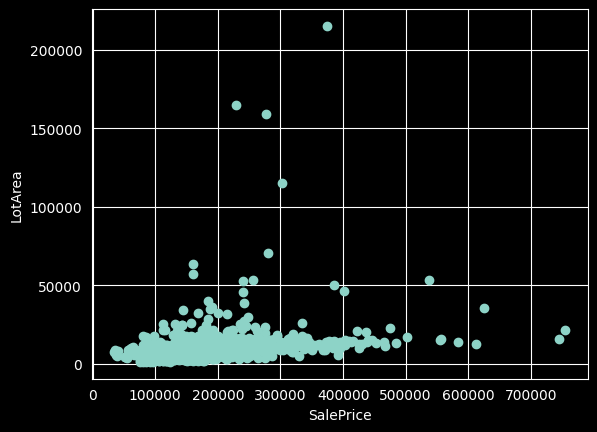

In [12]:
# SKIP THIS ---------------

# Exploring the relationship between the size of the lot and the price
print(train["SalePrice"].corr( train["LotArea"]))
plt.scatter(train["SalePrice"],train["LotArea"])
plt.xlabel("SalePrice")
plt.ylabel("LotArea")

# The correlation coefficient is pretty low. Some very evident outliers appear

# BUT THIS ONE is veeeery nice
print(sales_price.corr(train["GrLivArea"]))


0.7009266525441299


Text(0, 0.5, 'Above grade (ground) living area square feet')

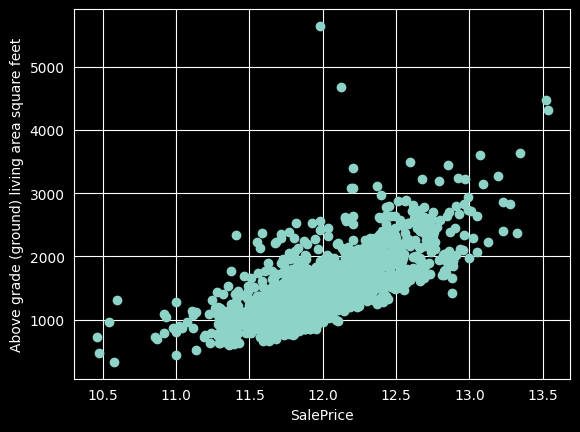

In [50]:
# SKIP THIS --------------- NO, WAIT! HAVE A LOOK

# Above grade (ground) living area square feet VS Price. THIS IS GOOD!!
print(sales_price.corr(train["GrLivArea"]))
plt.scatter(sales_price,train["GrLivArea"])
plt.xlabel("SalePrice")
plt.ylabel("Above grade (ground) living area square feet")




---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

In [15]:
# I've added Neighborhood and MSZoning to the proposed list of feature as they look somehow significant
features = ['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual','FireplaceQu', 'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold', 'Neighborhood', 'MSZoning']

df_anova = train[features + ["SalePrice_log"]].copy()
for col in features:
    if df_anova[col].dtype == "object" or df_anova[col].isnull().any():
        df_anova[col] = df_anova[col].fillna("None")

results = []
for col in features:
    groups = [group["SalePrice_log"].values for name, group in df_anova.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "p-value": p_val,
        "Significant (0.05)": p_val < 0.05
    })

anova_r = pd.DataFrame(results).sort_values(by="F-Statistic", ascending=False)
print(anova_r)



         Feature  F-Statistic        p-value  Significant (0.05)
1      ExterQual   415.303357  6.935425e-195                True
3    KitchenQual   393.320196  4.441486e-187                True
0    OverallQual   332.166377   0.000000e+00                True
2       BsmtQual   300.392324  2.031282e-188                True
5     CentralAir   205.666987   9.855628e-44                True
4    FireplaceQu   131.198459  6.963458e-115                True
10  Neighborhood    79.520424  4.043304e-243                True
11      MSZoning    77.607843   1.021343e-59                True
6       LotShape    46.728762   7.856968e-29                True
7      LandSlope     1.083039   3.388375e-01               False
8         MoSold     0.993740   4.496616e-01               False
9         YrSold     0.738616   5.656374e-01               False


,mean,min,max,std,count
ExterQual,,,,,
Ex,12.764044,11.982929,13.534473,0.325699,52
Fa,11.304541,10.578980,12.206073,0.406416,14
Gd,12.311282,10.858999,13.521139,0.285985,488
TA,11.837985,10.460242,12.850555,0.293697,906


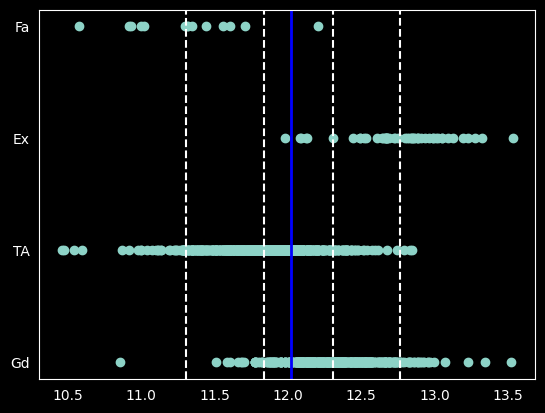

In [16]:
plt.scatter(train["SalePrice_log"],train["ExterQual"])
plt.axvline(mean_sales_price, color='blue', linewidth=2)
for line in train["SalePrice_log"].groupby(train["ExterQual"]).agg("mean"):
    plt.axvline(line,linestyle='--')
plt.grid(False)
train["SalePrice_log"].groupby(train["ExterQual"]).agg(["mean", "min", "max", "std", "count"])

               sum_sq      df           F         PR(>F)
ExterQual  107.349496     3.0  415.303357  6.935425e-195
Residual   125.451163  1456.0         NaN            NaN


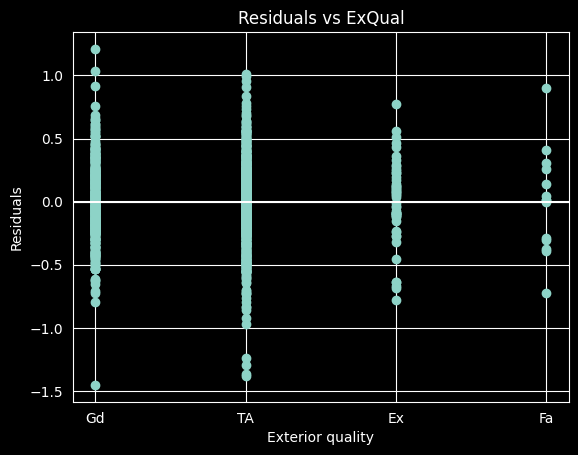

In [17]:
# Fit the one-way ANOVA model
model = ols('SalePrice_log ~ ExterQual', data=train).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues
plt.figure()
plt.scatter(train["ExterQual"], residuals)
plt.axhline(0)
plt.xlabel("Exterior quality")
plt.ylabel("Residuals")
plt.title("Residuals vs ExQual")
plt.show()


In [43]:
# So... ANOVA was fun. Let's see the results for all the columns!
all_features = train.columns.tolist()
all_features.remove("SalePrice_log")
all_features.remove("Id")

df_anova_total = train.copy()
for col in all_features:
    if df_anova_total[col].dtype == "object" or df_anova_total[col].isnull().any():
        df_anova_total[col] = df_anova_total[col].fillna("None")

results = []
for col in all_features:
    groups = [group["SalePrice_log"].values for name, group in df_anova_total.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    results.append({
        "Feature": col,
        "F-Statistic": f_stat,
        "p-value": p_val,
        "Significant (0.05)": p_val < 0.05
    })

anova_t = pd.DataFrame(results).sort_values(by="F-Statistic", ascending=False)
anova_t.head(30)

# I think we have some very interesting groups!!!

,Feature,F-Statistic,p-value,Significant (0.05)
79,SalePrice,inf,0.000000e+00,True
26,ExterQual,415.303357,6.935425e-195,True
52,KitchenQual,393.320196,4.441486e-187,True
60,GarageCars,349.636936,5.539585e-211,True
16,OverallQual,332.166377,0.000000e+00,True
29,BsmtQual,300.392324,2.031282e-188,True
59,GarageFinish,298.769753,4.057458e-151,True
48,FullBath,275.955870,8.569577e-142,True
40,CentralAir,205.666987,9.855628e-44,True
55,Fireplaces,174.940457,7.485912e-97,True


---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

0.7009266525441299


In [45]:
model_2f = ols("SalePrice_log ~ ExterQual * GrLivArea", data=train).fit()
anova_table = sm.stats.anova_lm(model_2f, typ=2)
print(anova_table)


                        sum_sq      df           F         PR(>F)
ExterQual            40.556456     3.0  266.517374  8.804385e-138
GrLivArea            47.581497     1.0  938.047637  2.444076e-159
ExterQual:GrLivArea   4.218465     3.0   27.721707   1.969380e-17
Residual             73.651200  1452.0         NaN            NaN


---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.